# Data Visualization Recorded Data

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Loading

In [3]:
df = pd.read_csv("data/300Hz_input_16_ch_2kHz_sampling_1kHz_fH_04.csv", sep=None, engine="python")

## Initial Data Inspection

In [4]:
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Detected separator — inferred from above")
df.head()

Shape: (43155, 17)
Columns: ['sample_num', 'ch0', 'ch1', 'ch2', 'ch3', 'ch4', 'ch5', 'ch6', 'ch7', 'ch8', 'ch9', 'ch10', 'ch11', 'ch12', 'ch13', 'ch14', 'ch15']
Detected separator — inferred from above


,sample_num,ch0,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8,ch9,ch10,ch11,ch12,ch13,ch14,ch15
0,0,3.0,-6389.0,-3764.0,-6389.0,-3506.0,-6311.0,-3032.0,284.0,-3395.0,-3815.0,-4271.0,-4132.0,-4043.0,-6054.0,-3213.0,-6389.0
1,1,3.0,-6389.0,-3673.0,-6389.0,-3422.0,-6314.0,-3045.0,203.0,-3430.0,-3827.0,-4252.0,-4091.0,-4023.0,-6160.0,-3260.0,-6389.0
2,2,4.0,-6389.0,-3690.0,-6389.0,-3410.0,-6389.0,-2961.0,-393.0,-3288.0,-3670.0,-4061.0,-3934.0,-3894.0,-6112.0,-3123.0,-6389.0
3,3,0.0,-6389.0,-3592.0,-6389.0,-3324.0,-6382.0,-2873.0,-1233.0,-3206.0,-3604.0,-4045.0,-3960.0,-3889.0,-6092.0,-3071.0,-5086.0
4,4,0.0,-6389.0,-3290.0,-6389.0,-2943.0,-5975.0,-2664.0,-1746.0,-2959.0,-3376.0,-3747.0,-3635.0,-3605.0,-5936.0,-2809.0,-2077.0


In [6]:
FS = 2000  # Hz, sampling rate

n_samples = len(df)
duration_ms = n_samples / FS * 1000

print(f"Samples:  {n_samples}")
print(f"Duration: {duration_ms:.1f} ms")

max_duration_ms = duration_ms  # used as upper bound in plotting cell

Samples:  43155
Duration: 21577.5 ms


## Plotting - 16 channels à 2 kHz

In [7]:
# ── Signal parameters ──────────────────────────────────────────────
FS          = 2000
F_INPUT     = 300    # Hz, input signal frequency
CHANNEL     = "ch7"  # which channel to plot

# ── Window ─────────────────────────────────────────────────────────
START_MS    = 15000      # ms, start of the plot window

N_CYCLES    = 10      # number of oscillations to show (takes priority if not None)
WINDOW_MS   = None   # ms, time window to show (used if N_CYCLES is None)

# ── Axis limits ────────────────────────────────────────────────────
Y_MIN       = None   # µV, set to None for auto
Y_MAX       = None   # µV, set to None for auto

# ── Figure style ───────────────────────────────────────────────────
FIG_WIDTH   = 8      # inches
FIG_HEIGHT  = 3      # inches
LINE_WIDTH  = 1.2    # pt
LINE_COLOR  = "black"

FONT_SIZE_LABEL  = 12  # axis label font size
FONT_SIZE_TICK   = 10  # tick label font size
FONT_SIZE_TITLE  = 13  # title font size

SHOW_GRID   = True
SHOW_TITLE  = None

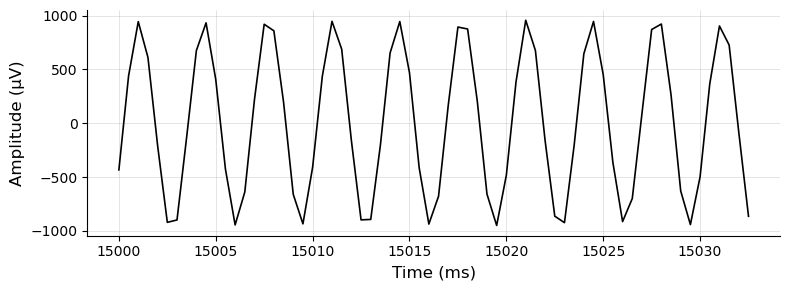

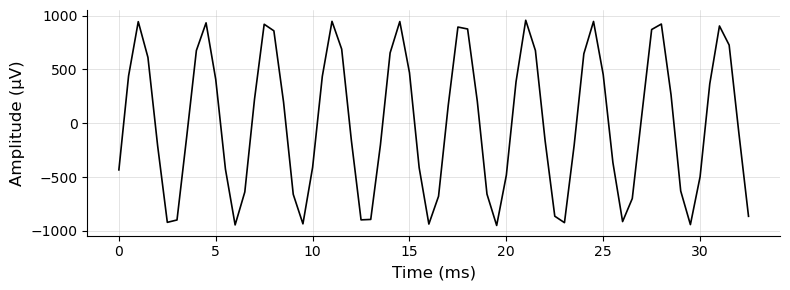

In [8]:
# ── Derived quantities ─────────────────────────────────────────────
if N_CYCLES is not None:
    window_ms = N_CYCLES / F_INPUT * 1000
else:
    window_ms = WINDOW_MS

end_ms = START_MS + window_ms
assert end_ms <= max_duration_ms, (
    f"Window end ({end_ms:.1f} ms) exceeds recording length ({max_duration_ms:.1f} ms)"
)

# ── Slice data ─────────────────────────────────────────────────────
start_idx = int(START_MS / 1000 * FS)
end_idx   = int(end_ms   / 1000 * FS)

time_ms = np.arange(start_idx, end_idx) / FS * 1000  # ms
signal  = df[CHANNEL].iloc[start_idx:end_idx].values  # µV

# ── Plot ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

ax.plot(time_ms, signal, linewidth=LINE_WIDTH, color=LINE_COLOR)

ax.set_xlabel("Time (ms)", fontsize=FONT_SIZE_LABEL)
ax.set_ylabel("Amplitude (µV)", fontsize=FONT_SIZE_LABEL)
ax.tick_params(labelsize=FONT_SIZE_TICK)

if Y_MIN is not None or Y_MAX is not None:
    ax.set_ylim(Y_MIN, Y_MAX)

if SHOW_TITLE:
    title = (f"{CHANNEL} — {F_INPUT} Hz input, "
             f"f_s = {FS} Hz, "
             f"{N_CYCLES} cycles" if N_CYCLES else f"{window_ms:.1f} ms window")
    ax.set_title(title, fontsize=FONT_SIZE_TITLE)

if SHOW_GRID:
    ax.grid(True, linewidth=0.4, alpha=0.6)

ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# ── Same plot with x-axis starting at 0 ───────────────────────────
time_ms_zeroed = time_ms - time_ms[0]

fig2, ax2 = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

ax2.plot(time_ms_zeroed, signal, linewidth=LINE_WIDTH, color=LINE_COLOR)

ax2.set_xlabel("Time (ms)", fontsize=FONT_SIZE_LABEL)
ax2.set_ylabel("Amplitude (µV)", fontsize=FONT_SIZE_LABEL)
ax2.tick_params(labelsize=FONT_SIZE_TICK)

if Y_MIN is not None or Y_MAX is not None:
    ax2.set_ylim(Y_MIN, Y_MAX)

if SHOW_TITLE:
    ax2.set_title(title, fontsize=FONT_SIZE_TITLE)

if SHOW_GRID:
    ax2.grid(True, linewidth=0.4, alpha=0.6)

ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [9]:
# ── Sine fit style ─────────────────────────────────────────────────
SINE_COLOR      = "#E84A2F"   # color of the reference sine
SINE_LINE_STYLE = "--"        # linestyle for reference sine
SINE_LINE_WIDTH = 1.2         # pt
SINE_AMPLITUDE  = 1000        # µV, known input amplitude

SIGNAL_COLOR_OVERLAY = "black"
SIGNAL_LINE_WIDTH_OVERLAY = 1.2

LEGEND_FONT_SIZE = 10
LEGEND_LOCATION  = "upper right"  # "upper right", "lower right", etc.

SINE_OVERSAMPLE = 100  # factor above FS for the reference sine (higher = smoother curve)

# inherits FIG_WIDTH, FIG_HEIGHT, FONT_SIZE_LABEL, FONT_SIZE_TICK,
# FONT_SIZE_TITLE, SHOW_GRID, Y_MIN, Y_MAX from Cell 5

Target FFT bin: 10  (303.03 Hz)
Phase offset:   -28.26°


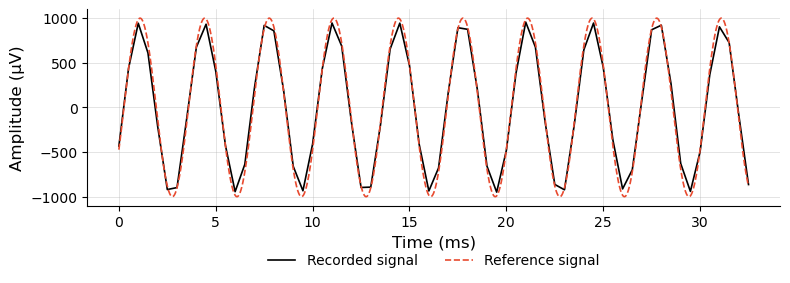

In [10]:
LEGEND_NCOL = 2   # number of columns in the legend

# ── Build reference sine on signal grid ───────────────────────────
n_samples_window = len(signal)
t_local = np.arange(n_samples_window) / FS
t_hires = np.linspace(0, t_local[-1],
                      n_samples_window * SINE_OVERSAMPLE)

ref_sine = np.sin(2 * np.pi * F_INPUT * t_local)

# ── FFT-based phase estimation (exact, no sample quantization) ─────
freq_resolution = FS / n_samples_window
target_bin      = round(F_INPUT / freq_resolution)

S = np.fft.rfft(signal - signal.mean())
R = np.fft.rfft(ref_sine)

phase_offset = np.angle(S[target_bin]) - np.angle(R[target_bin])

# ── Build fitted sine on high-res grid ────────────────────────────
fitted_sine = SINE_AMPLITUDE * np.sin(2 * np.pi * F_INPUT * t_hires + phase_offset)

print(f"Target FFT bin: {target_bin}  ({target_bin * freq_resolution:.2f} Hz)")
print(f"Phase offset:   {np.degrees(phase_offset):.2f}°")

# ── Plot ───────────────────────────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

ax3.plot(time_ms_zeroed, signal,
         color=SIGNAL_COLOR_OVERLAY,
         linewidth=SIGNAL_LINE_WIDTH_OVERLAY,
         label="Recorded signal")

ax3.plot(t_hires * 1000, fitted_sine,
         color=SINE_COLOR,
         linewidth=SINE_LINE_WIDTH,
         linestyle=SINE_LINE_STYLE,
         label="Reference signal")

ax3.set_xlabel("Time (ms)", fontsize=FONT_SIZE_LABEL)
ax3.set_ylabel("Amplitude (µV)", fontsize=FONT_SIZE_LABEL)
ax3.tick_params(labelsize=FONT_SIZE_TICK)

if Y_MIN is not None or Y_MAX is not None:
    ax3.set_ylim(Y_MIN, Y_MAX)

if SHOW_TITLE:
    ax3.set_title(f"{CHANNEL} vs. reference signal — phase offset {np.degrees(phase_offset):.1f}°",
                  fontsize=FONT_SIZE_TITLE)

ax3.legend(fontsize=LEGEND_FONT_SIZE,
           loc="upper center",
           bbox_to_anchor=(0.5, -0.18),
           ncol=LEGEND_NCOL,
           frameon=False)

if SHOW_GRID:
    ax3.grid(True, linewidth=0.4, alpha=0.6)

ax3.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [11]:
# ── Amplitude fit style ────────────────────────────────────────────
SINE_COLOR_FITTED      = "#2F7BE8"   # color of the amplitude-fitted sine
SINE_LINE_STYLE_FITTED = "--"
SINE_LINE_WIDTH_FITTED = 1.2

# inherits all other style params from Cell 5 and Cell 7

Fitted amplitude:    964.76 ± 6.66 µV  (input: 1000 µV)
Fitted phase offset: -28.11 ± 0.39°
Amplitude error:     35.24 µV  (3.52%)


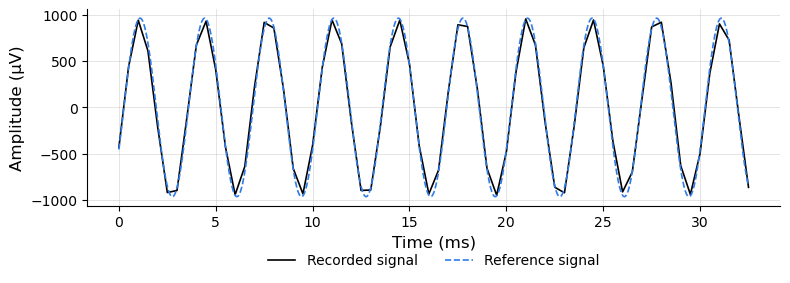

In [12]:
from scipy.optimize import curve_fit

# ── Model: A * sin(2π f t + φ) ─────────────────────────────────────
def sine_model(t, amplitude, phase):
    return amplitude * np.sin(2 * np.pi * F_INPUT * t + phase)

# ── Initial guess: use cross-correlation phase from Cell 8 ─────────
p0 = [SINE_AMPLITUDE, phase_offset]

popt, pcov = curve_fit(sine_model, t_local, signal, p0=p0)
perr       = np.sqrt(np.diag(pcov))

A_fit   = popt[0]
phi_fit = popt[1]
A_err   = perr[0]
phi_err = perr[1]

print(f"Fitted amplitude:    {A_fit:.2f} ± {A_err:.2f} µV  (input: {SINE_AMPLITUDE} µV)")
print(f"Fitted phase offset: {np.degrees(phi_fit):.2f} ± {np.degrees(phi_err):.2f}°")
print(f"Amplitude error:     {abs(A_fit - SINE_AMPLITUDE):.2f} µV  "
      f"({abs(A_fit - SINE_AMPLITUDE) / SINE_AMPLITUDE * 100:.2f}%)")

# ── Build fitted sine on high-res grid ────────────────────────────
fitted_sine_ls = sine_model(t_hires, A_fit, phi_fit)

# ── Plot ───────────────────────────────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

ax4.plot(time_ms_zeroed, signal,
         color=SIGNAL_COLOR_OVERLAY,
         linewidth=SIGNAL_LINE_WIDTH_OVERLAY,
         label="Recorded signal")

ax4.plot(t_hires * 1000, fitted_sine_ls,
         color=SINE_COLOR_FITTED,
         linewidth=SINE_LINE_WIDTH_FITTED,
         linestyle=SINE_LINE_STYLE_FITTED,
         label="Reference signal")

ax4.set_xlabel("Time (ms)", fontsize=FONT_SIZE_LABEL)
ax4.set_ylabel("Amplitude (µV)", fontsize=FONT_SIZE_LABEL)
ax4.tick_params(labelsize=FONT_SIZE_TICK)

if Y_MIN is not None or Y_MAX is not None:
    ax4.set_ylim(Y_MIN, Y_MAX)

if SHOW_TITLE:
    ax4.set_title(f"{CHANNEL} — fitted amplitude: {A_fit:.0f} µV, "
                  f"φ = {np.degrees(phi_fit):.1f}°",
                  fontsize=FONT_SIZE_TITLE)

ax4.legend(fontsize=LEGEND_FONT_SIZE,
           loc="upper center",
           bbox_to_anchor=(0.5, -0.18),
           ncol=LEGEND_NCOL,
           frameon=False)

if SHOW_GRID:
    ax4.grid(True, linewidth=0.4, alpha=0.6)

ax4.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## Plotting - 8 channels à 4 kHz

In [23]:
df = pd.read_csv("data/300Hz_input_8_ch_4kHz_sampling_2kHz_fH_04.csv", sep=None, engine="python")

In [24]:
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Detected separator — inferred from above")
df.head()

Shape: (170716, 9)
Columns: ['sample_num', 'ch0', 'ch7', 'ch10', 'ch11', 'ch12', 'ch13', 'ch14', 'ch15']
Detected separator — inferred from above


,sample_num,ch0,ch7,ch10,ch11,ch12,ch13,ch14,ch15
0,0,-7.0,385.0,-6336.0,-5662.0,-6189.0,-6389.0,-5086.0,-6389.0
1,1,-1.0,-538.0,-6361.0,-5591.0,-6095.0,-6389.0,-4994.0,-6389.0
2,2,-3.0,-818.0,-6284.0,-5544.0,-6047.0,-6389.0,-4952.0,-6389.0
3,3,-3.0,-1313.0,-6249.0,-5499.0,-5977.0,-6389.0,-4897.0,-6389.0
4,4,0.0,-1741.0,-6158.0,-5428.0,-5917.0,-6389.0,-4846.0,-6389.0


In [25]:
FS = 4000  # Hz, sampling rate

n_samples = len(df)
duration_ms = n_samples / FS * 1000

print(f"Samples:  {n_samples}")
print(f"Duration: {duration_ms:.1f} ms")

max_duration_ms = duration_ms  # used as upper bound in plotting cell

Samples:  170716
Duration: 42679.0 ms


In [32]:
# ── Signal parameters ──────────────────────────────────────────────
FS          = 4000
F_INPUT     = 300    # Hz, input signal frequency
CHANNEL     = "ch7"  # which channel to plot

# ── Window ─────────────────────────────────────────────────────────
START_MS    = 16000      # ms, start of the plot window

N_CYCLES    = 10      # number of oscillations to show (takes priority if not None)
WINDOW_MS   = None   # ms, time window to show (used if N_CYCLES is None)

# ── Axis limits ────────────────────────────────────────────────────
Y_MIN       = None   # µV, set to None for auto
Y_MAX       = None   # µV, set to None for auto

# ── Figure style ───────────────────────────────────────────────────
FIG_WIDTH   = 8      # inches
FIG_HEIGHT  = 3      # inches
LINE_WIDTH  = 1.2    # pt
LINE_COLOR  = "black"

FONT_SIZE_LABEL  = 12  # axis label font size
FONT_SIZE_TICK   = 10  # tick label font size
FONT_SIZE_TITLE  = 13  # title font size

SHOW_GRID   = True
SHOW_TITLE  = None

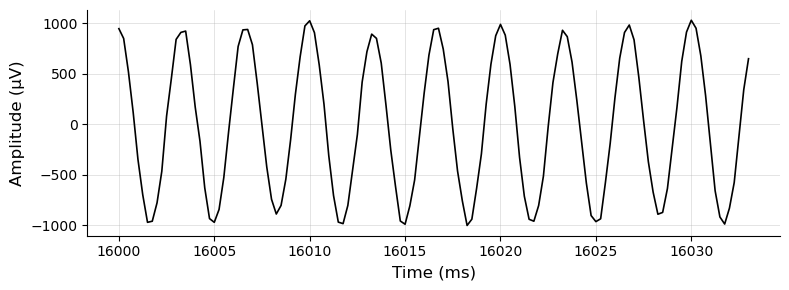

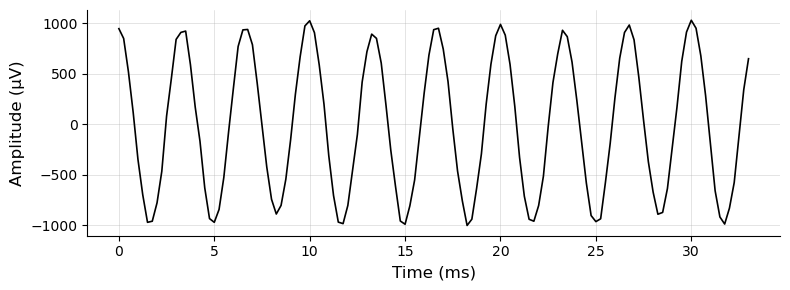

In [33]:
# ── Derived quantities ─────────────────────────────────────────────
if N_CYCLES is not None:
    window_ms = N_CYCLES / F_INPUT * 1000
else:
    window_ms = WINDOW_MS

end_ms = START_MS + window_ms
assert end_ms <= max_duration_ms, (
    f"Window end ({end_ms:.1f} ms) exceeds recording length ({max_duration_ms:.1f} ms)"
)

# ── Slice data ─────────────────────────────────────────────────────
start_idx = int(START_MS / 1000 * FS)
end_idx   = int(end_ms   / 1000 * FS)

time_ms = np.arange(start_idx, end_idx) / FS * 1000  # ms
signal  = df[CHANNEL].iloc[start_idx:end_idx].values  # µV

# ── Plot ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

ax.plot(time_ms, signal, linewidth=LINE_WIDTH, color=LINE_COLOR)

ax.set_xlabel("Time (ms)", fontsize=FONT_SIZE_LABEL)
ax.set_ylabel("Amplitude (µV)", fontsize=FONT_SIZE_LABEL)
ax.tick_params(labelsize=FONT_SIZE_TICK)

if Y_MIN is not None or Y_MAX is not None:
    ax.set_ylim(Y_MIN, Y_MAX)

if SHOW_TITLE:
    title = (f"{CHANNEL} — {F_INPUT} Hz input, "
             f"f_s = {FS} Hz, "
             f"{N_CYCLES} cycles" if N_CYCLES else f"{window_ms:.1f} ms window")
    ax.set_title(title, fontsize=FONT_SIZE_TITLE)

if SHOW_GRID:
    ax.grid(True, linewidth=0.4, alpha=0.6)

ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# ── Same plot with x-axis starting at 0 ───────────────────────────
time_ms_zeroed = time_ms - time_ms[0]

fig2, ax2 = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

ax2.plot(time_ms_zeroed, signal, linewidth=LINE_WIDTH, color=LINE_COLOR)

ax2.set_xlabel("Time (ms)", fontsize=FONT_SIZE_LABEL)
ax2.set_ylabel("Amplitude (µV)", fontsize=FONT_SIZE_LABEL)
ax2.tick_params(labelsize=FONT_SIZE_TICK)

if Y_MIN is not None or Y_MAX is not None:
    ax2.set_ylim(Y_MIN, Y_MAX)

if SHOW_TITLE:
    ax2.set_title(title, fontsize=FONT_SIZE_TITLE)

if SHOW_GRID:
    ax2.grid(True, linewidth=0.4, alpha=0.6)

ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [34]:
# ── Sine fit style ─────────────────────────────────────────────────
SINE_COLOR      = "#E84A2F"   # color of the reference sine
SINE_LINE_STYLE = "--"        # linestyle for reference sine
SINE_LINE_WIDTH = 1.2         # pt
SINE_AMPLITUDE  = 1000        # µV, known input amplitude

SIGNAL_COLOR_OVERLAY = "black"
SIGNAL_LINE_WIDTH_OVERLAY = 1.2

LEGEND_FONT_SIZE = 10
LEGEND_LOCATION  = "upper right"  # "upper right", "lower right", etc.

SINE_OVERSAMPLE = 100  # factor above FS for the reference sine (higher = smoother curve)

# inherits FIG_WIDTH, FIG_HEIGHT, FONT_SIZE_LABEL, FONT_SIZE_TICK,
# FONT_SIZE_TITLE, SHOW_GRID, Y_MIN, Y_MAX from Cell 5

Target FFT bin: 10  (300.75 Hz)
Phase offset:   90.54°


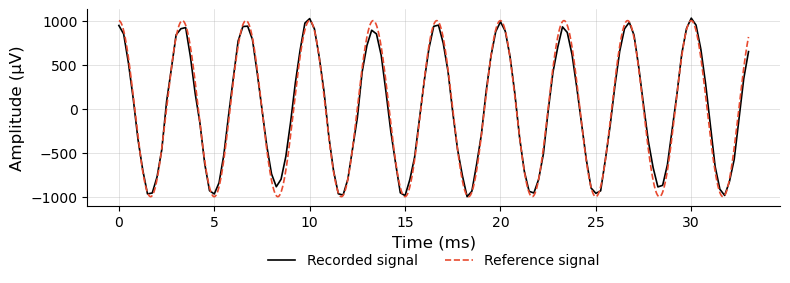

In [35]:
LEGEND_NCOL = 2   # number of columns in the legend

# ── Build reference sine on signal grid ───────────────────────────
n_samples_window = len(signal)
t_local = np.arange(n_samples_window) / FS
t_hires = np.linspace(0, t_local[-1],
                      n_samples_window * SINE_OVERSAMPLE)

ref_sine = np.sin(2 * np.pi * F_INPUT * t_local)

# ── FFT-based phase estimation (exact, no sample quantization) ─────
freq_resolution = FS / n_samples_window
target_bin      = round(F_INPUT / freq_resolution)

S = np.fft.rfft(signal - signal.mean())
R = np.fft.rfft(ref_sine)

phase_offset = np.angle(S[target_bin]) - np.angle(R[target_bin])

# ── Build fitted sine on high-res grid ────────────────────────────
fitted_sine = SINE_AMPLITUDE * np.sin(2 * np.pi * F_INPUT * t_hires + phase_offset)

print(f"Target FFT bin: {target_bin}  ({target_bin * freq_resolution:.2f} Hz)")
print(f"Phase offset:   {np.degrees(phase_offset):.2f}°")

# ── Plot ───────────────────────────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

ax3.plot(time_ms_zeroed, signal,
         color=SIGNAL_COLOR_OVERLAY,
         linewidth=SIGNAL_LINE_WIDTH_OVERLAY,
         label="Recorded signal")

ax3.plot(t_hires * 1000, fitted_sine,
         color=SINE_COLOR,
         linewidth=SINE_LINE_WIDTH,
         linestyle=SINE_LINE_STYLE,
         label="Reference signal")

ax3.set_xlabel("Time (ms)", fontsize=FONT_SIZE_LABEL)
ax3.set_ylabel("Amplitude (µV)", fontsize=FONT_SIZE_LABEL)
ax3.tick_params(labelsize=FONT_SIZE_TICK)

if Y_MIN is not None or Y_MAX is not None:
    ax3.set_ylim(Y_MIN, Y_MAX)

if SHOW_TITLE:
    ax3.set_title(f"{CHANNEL} vs. reference signal — phase offset {np.degrees(phase_offset):.1f}°",
                  fontsize=FONT_SIZE_TITLE)

ax3.legend(fontsize=LEGEND_FONT_SIZE,
           loc="upper center",
           bbox_to_anchor=(0.5, -0.18),
           ncol=LEGEND_NCOL,
           frameon=False)

if SHOW_GRID:
    ax3.grid(True, linewidth=0.4, alpha=0.6)

ax3.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [36]:
# ── Amplitude fit style ────────────────────────────────────────────
SINE_COLOR_FITTED      = "#2F7BE8"   # color of the amplitude-fitted sine
SINE_LINE_STYLE_FITTED = "--"
SINE_LINE_WIDTH_FITTED = 1.2

# inherits all other style params from Cell 5 and Cell 7

Fitted amplitude:    965.46 ± 7.33 µV  (input: 1000 µV)
Fitted phase offset: 90.63 ± 0.43°
Amplitude error:     34.54 µV  (3.45%)


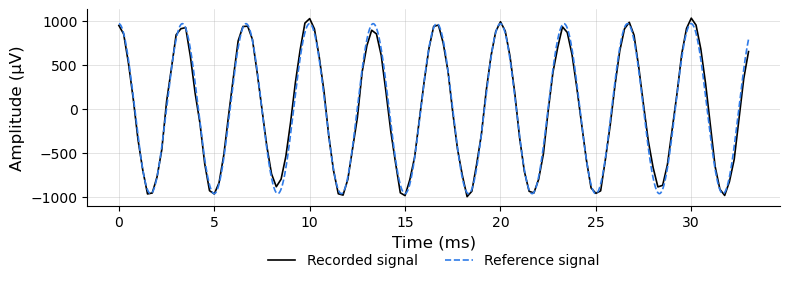

In [37]:
from scipy.optimize import curve_fit

# ── Model: A * sin(2π f t + φ) ─────────────────────────────────────
def sine_model(t, amplitude, phase):
    return amplitude * np.sin(2 * np.pi * F_INPUT * t + phase)

# ── Initial guess: use cross-correlation phase from Cell 8 ─────────
p0 = [SINE_AMPLITUDE, phase_offset]

popt, pcov = curve_fit(sine_model, t_local, signal, p0=p0)
perr       = np.sqrt(np.diag(pcov))

A_fit   = popt[0]
phi_fit = popt[1]
A_err   = perr[0]
phi_err = perr[1]

print(f"Fitted amplitude:    {A_fit:.2f} ± {A_err:.2f} µV  (input: {SINE_AMPLITUDE} µV)")
print(f"Fitted phase offset: {np.degrees(phi_fit):.2f} ± {np.degrees(phi_err):.2f}°")
print(f"Amplitude error:     {abs(A_fit - SINE_AMPLITUDE):.2f} µV  "
      f"({abs(A_fit - SINE_AMPLITUDE) / SINE_AMPLITUDE * 100:.2f}%)")

# ── Build fitted sine on high-res grid ────────────────────────────
fitted_sine_ls = sine_model(t_hires, A_fit, phi_fit)

# ── Plot ───────────────────────────────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

ax4.plot(time_ms_zeroed, signal,
         color=SIGNAL_COLOR_OVERLAY,
         linewidth=SIGNAL_LINE_WIDTH_OVERLAY,
         label="Recorded signal")

ax4.plot(t_hires * 1000, fitted_sine_ls,
         color=SINE_COLOR_FITTED,
         linewidth=SINE_LINE_WIDTH_FITTED,
         linestyle=SINE_LINE_STYLE_FITTED,
         label="Reference signal")

ax4.set_xlabel("Time (ms)", fontsize=FONT_SIZE_LABEL)
ax4.set_ylabel("Amplitude (µV)", fontsize=FONT_SIZE_LABEL)
ax4.tick_params(labelsize=FONT_SIZE_TICK)

if Y_MIN is not None or Y_MAX is not None:
    ax4.set_ylim(Y_MIN, Y_MAX)

if SHOW_TITLE:
    ax4.set_title(f"{CHANNEL} — fitted amplitude: {A_fit:.0f} µV, "
                  f"φ = {np.degrees(phi_fit):.1f}°",
                  fontsize=FONT_SIZE_TITLE)

ax4.legend(fontsize=LEGEND_FONT_SIZE,
           loc="upper center",
           bbox_to_anchor=(0.5, -0.18),
           ncol=LEGEND_NCOL,
           frameon=False)

if SHOW_GRID:
    ax4.grid(True, linewidth=0.4, alpha=0.6)

ax4.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()